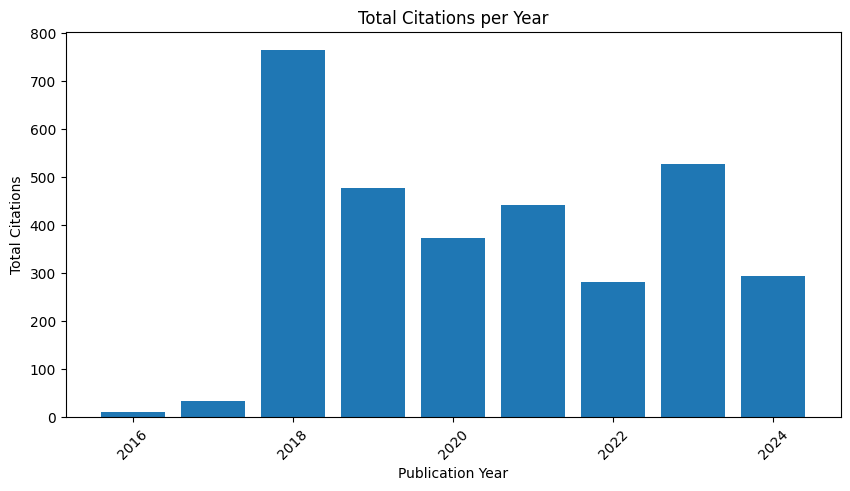

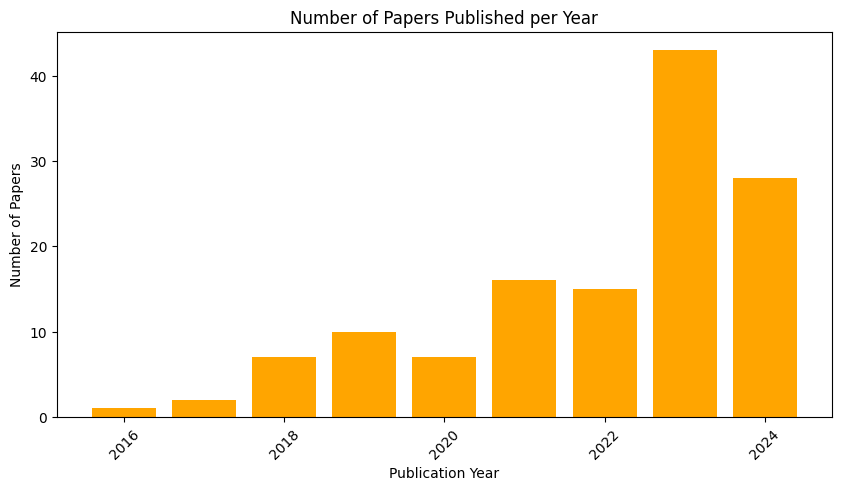

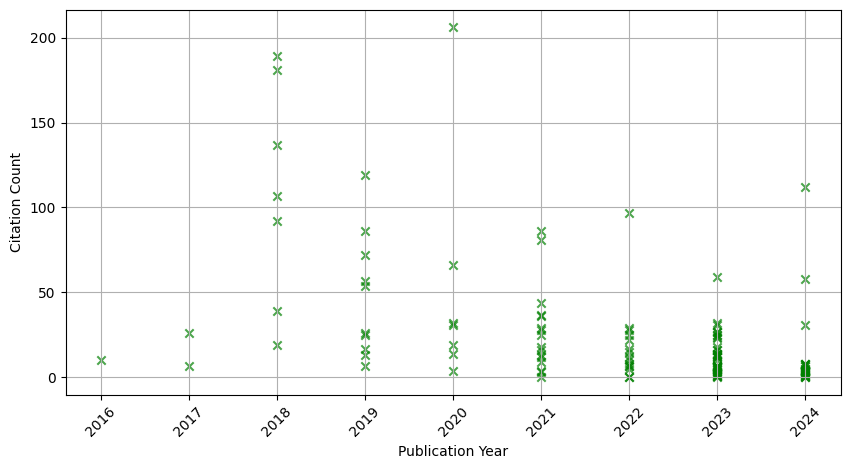

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "citation counts.xlsx"
xls = pd.ExcelFile(file_path)
df = pd.read_excel(xls, sheet_name='Sheet1')

# Aggregate citation count by publication year
yearly_citations = df.groupby("Publication Year")["Citation Count (as of 02 March 2025)"].sum()

# Plot total citations per year
plt.figure(figsize=(10, 5))
plt.bar(yearly_citations.index, yearly_citations.values)
plt.xlabel("Publication Year")
plt.ylabel("Total Citations")
plt.title("Total Citations per Year")
plt.xticks(rotation=45)
plt.show()

# Count the number of papers per publication year
paper_counts = df["Publication Year"].value_counts().sort_index()

# Plot number of papers per year
plt.figure(figsize=(10, 5))
plt.bar(paper_counts.index, paper_counts.values, color="orange")
plt.xlabel("Publication Year")
plt.ylabel("Number of Papers")
plt.title("Number of Papers Published per Year")
plt.xticks(rotation=45)
plt.show()

# Scatter plot of individual paper citations per year
plt.figure(figsize=(10, 5))
plt.scatter(df["Publication Year"], df["Citation Count (as of 02 March 2025)"], marker= 'x', alpha=0.7, color="green")
plt.xlabel("Publication Year")
plt.ylabel("Citation Count")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [7]:
import pandas as pd

def calculate_ncr(input_path, output_path, method='mean'):
    """
    Process citation data and calculate Normalized Citation Ratio (NCR)
    
    Parameters:
    input_path (str): Path to input Excel file
    output_path (str): Path to save output Excel file
    method (str): 'mean' or 'median' for cohort comparison
    """
    
    df = pd.read_excel(input_path)
    df['Paper_Age'] = 2025 - df['Publication Year']
    cohort_stats = df.groupby('Publication Year')['Citation Count (as of 02 March 2025)'].agg(
        Cohort_Mean='mean',
        Cohort_Median='median',
        Cohort_Size='count'
    ).reset_index()
    
    # Merge stats back to original dataframe
    df = df.merge(cohort_stats, on='Publication Year')
    
    # Calculate Normalized Citation Ratio
    if method == 'median':
        denominator = df['Cohort_Median']
    else:
        denominator = df['Cohort_Mean']
    # Add small epsilon to avoid division by zero
    denominator = denominator + 1e-6
    df['NCR'] = df['Citation Count (as of 02 March 2025)'] / denominator
    
    # Calculate percentile rank within cohort
    df['Percentile_Rank'] = df.groupby('Publication Year')['Citation Count (as of 02 March 2025)'].rank(
        pct=True, method='dense'
    )
    # Sort by NCR (highest first)
    df = df.sort_values(by='NCR', ascending=False)    
    df.to_excel(output_path, index=False)
    print(f"Processed data saved to {output_path}")
    return df

if __name__ == "__main__":
    input_file = "citation counts.xlsx"
    output_file = "citation_data_with_ncr.xlsx"    
    processed_df = calculate_ncr(input_file, output_file, method='mean')

Processed data saved to citation_data_with_ncr.xlsx
